## ==========================================================
## 🎟️ Hopify (SaaS) Support Ticket Volume & Resolution Time by Segment
## ==========================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties

## ================================
## 📁 Set Base Path to Project Root
## ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📥 Load Data
## ==================================================

In [2]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "03_project_product_cust_behavior_insights",
    "11_hopify_supp_tckt_vol_v_avg_resolv_seg.csv"
)

df = pd.read_csv(file_path)

# ================================
# 🧼 Clean Columns
# ================================

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.rename(columns={
    'customer_segment': 'segment',
    'total_support_tickets': 'total_support_tickets',
    'avg_resolution_days': 'avg_resolution_days'
}, inplace=True)

# Normalize segment names
df['segment'] = df['segment'].str.title().str.replace("Smb", "SMB")

segments = ["Enterprise", "Mid-Market", "SMB"]
palette = {
    "Enterprise": "#ff7f0e",
    "Mid-Market": "#1f77b4",
    "SMB": "#9467bd"
}
df['segment'] = pd.Categorical(df['segment'], categories=segments, ordered=True)


## ==================================================
## 📊 Plot
## ==================================================

/var/folders/z4/bhxvrvmn0n30jr8zdx9wy1x80000gn/T/ipykernel_12698/1304826216.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar1 = sns.barplot(
/var/folders/z4/bhxvrvmn0n30jr8zdx9wy1x80000gn/T/ipykernel_12698/1304826216.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar2 = sns.barplot(


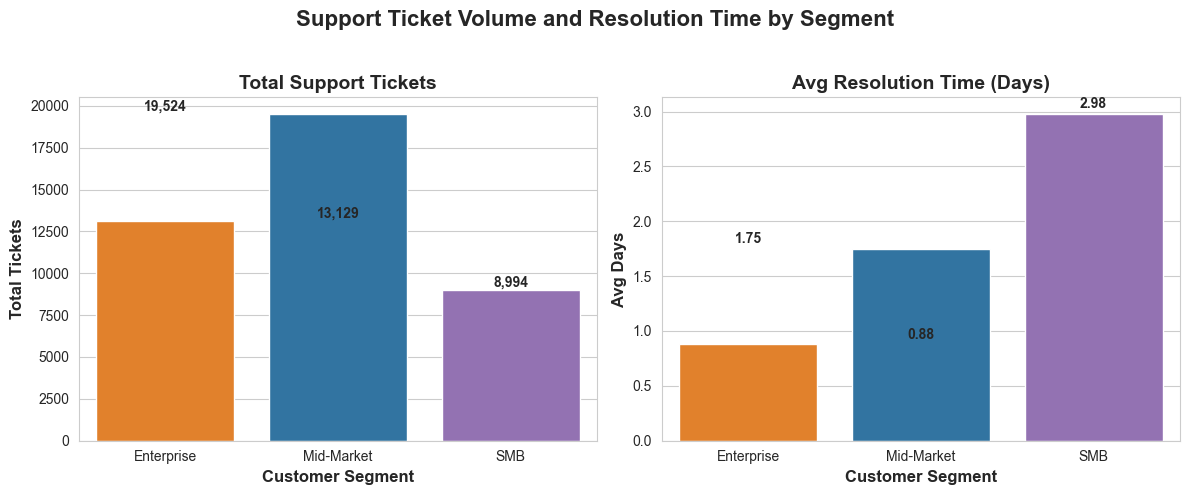

In [4]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

# Plot 1: Total Support Tickets
bar1 = sns.barplot(
    data=df,
    x='segment',
    y='total_support_tickets',
    order=segments,
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("Total Support Tickets", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Customer Segment", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Total Tickets", fontsize=12, fontweight='bold')

for i, row in df.iterrows():
    bar1.text(i, row["total_support_tickets"] + 200, f"{int(row['total_support_tickets']):,}",
              ha="center", fontsize=10, fontweight="bold")

# Plot 2: Avg Resolution Days
bar2 = sns.barplot(
    data=df,
    x='segment',
    y='avg_resolution_days',
    order=segments,
    palette=palette,
    ax=axes[1]
)
axes[1].set_title("Avg Resolution Time (Days)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Customer Segment", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Avg Days", fontsize=12, fontweight='bold')

for i, row in df.iterrows():
    bar2.text(i, row["avg_resolution_days"] + 0.05, f"{row['avg_resolution_days']:.2f}",
              ha="center", fontsize=10, fontweight="bold")

# ================================
# 🧾 Final Touches
# ================================

plt.suptitle("Support Ticket Volume and Resolution Time by Segment", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])


## ================================
## 💾 Save & Show
## ================================

In [5]:
output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "03_project_product_cust_behavior_insights",
    "hopify_support_volume_resolution_seg.png"
)
plt.savefig(output_path, dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>